In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import random
%matplotlib inline
%matplotlib ipympl
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [93]:
data = pd.read_csv("data.csv")
events = pd.read_csv("events.csv")

print("DATA columns:")
print(data.columns.tolist())

print("\nEVENTS columns:")
print(events.columns.tolist())

DATA columns:
['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item', 'product_id', 'inventory_item_id', 'sale_price', 'id', 'first_name', 'last_name', 'email', 'age', 'state', 'street_address', 'postal_code', 'city', 'country', 'traffic_source', 'user_geom', 'cost', 'category', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'sold_at', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id', 'distribution_center_geom', 'order_item_id', 'delivery_longitude', 'delivery_latitude', 'warehouse_name', 'warehouse_longitude', 'warehouse_latitude', 'is_loyal', 'product_name_clean', 'customer_review']

EVENTS columns:
['id', 'user_id', 'sequence_number', 'session_id', 'created_at', 'ip_address', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']


In [94]:
class RepeatPurchasePreprocessor:
    def __init__(self):
        self.columns = [
            "user_id",
            "order_id",
            "status",
            "age",
            "is_loyal",
            "country",
            "city",
            "traffic_source",
            "created_at",
            "shipped_at",
            "returned_at",
            "sale_price",
            "cost",
            "order_item_id"
        ]

        self.valid_status = [
            "Shipped",
            "Complete",
            "Cancelled",
            "Returned",
            "Processing"
        ]

        self.churn_window_days = None

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        df = df[self.columns]
        df = df.drop_duplicates()
        df = df[df["status"].isin(self.valid_status)].copy()

        for col in ["created_at", "shipped_at", "returned_at"]:
            df[col] = pd.to_datetime(df[col], errors="coerce")

        df = df[df["created_at"].notna()].copy()

        # =========================
        # ITEM-LEVEL FEATURES
        # =========================
        df["item_margin"] = df["sale_price"] - df["cost"]

        # =========================
        # ORDER-LEVEL FEATURES
        # =========================
        orders = (
            df.groupby(["user_id", "order_id"])
            .agg(
                created_at=("created_at", "min"),

                age=("age", "first"),
                is_loyal=("is_loyal", "max"),
                country=("country", "first"),
                city=("city", "first"),
                traffic_source=("traffic_source", "first"),

                total_items=("order_item_id", "count"),
                total_margin=("item_margin", "sum")
            )
            .reset_index()
        )

        # =========================
        # USER HISTORY
        # =========================
        orders = (
            orders
            .sort_values(["user_id", "created_at"])
            .reset_index(drop=True)
        )

        g = orders.groupby("user_id")

        orders["order_number"] = g.cumcount() + 1
        orders["total_orders_user"] = g["order_id"].transform("count")

        prev_count = g.cumcount()
        prev_count_safe = prev_count.replace(0, np.nan)

        orders["user_orders_before"] = prev_count

        orders["user_avg_items_before"] = (
            (g["total_items"].cumsum() - orders["total_items"])
            / prev_count_safe
        )

        orders["user_avg_margin_before"] = (
            (g["total_margin"].cumsum() - orders["total_margin"])
            / prev_count_safe
        )

        orders["days_since_prev_order"] = (
            g["created_at"].diff().dt.days
        )

        today = orders["created_at"].max()

        orders["days_since_order"] = (
            today - orders["created_at"]
        ).dt.days

        orders["month"] = orders["created_at"].dt.month

        # =========================
        # TARGET
        # =========================
        valid_intervals = orders.loc[
            orders["days_since_prev_order"] > 0,
            "days_since_prev_order"
        ]

        if len(valid_intervals) == 0:
            self.churn_window_days = 30
        else:
            self.churn_window_days = int(valid_intervals.median())

        orders["has_next_order"] = (
            orders["order_number"] < orders["total_orders_user"]
        ).astype(int)

        orders = orders[
            (orders["has_next_order"] == 1)
            | (orders["days_since_order"] >= self.churn_window_days)
        ].copy()

        orders["will_return"] = np.where(
            orders["has_next_order"] == 1,
            1,
            0
        )

        # =========================
        # FILL MISSING
        # =========================
        numeric_cols = orders.select_dtypes(include=[np.number]).columns.tolist()

        if "will_return" in numeric_cols:
            numeric_cols.remove("will_return")

        categorical_cols = [
            "country",
            "city",
            "traffic_source"
        ]

        orders[numeric_cols] = orders[numeric_cols].fillna(0)

        for col in categorical_cols:
            orders[col] = orders[col].fillna("Unknown").astype(str)

        return orders.reset_index(drop=True)

In [95]:
class RepeatPurchaseModel:
    def __init__(self):
        self.feature_cols = [
            "is_loyal",
            "days_since_order",
            "total_items",
            "user_orders_before",
            "user_avg_items_before",
            "user_avg_margin_before",
            "days_since_prev_order",
            "month",
            "age",
            "city",
            "country",
            "traffic_source"
        ]

        self.cat_features = [
            "country",
            "city",
            "traffic_source"
        ]

        self.model_params = {
            "iterations": 1000,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 8,
            "bagging_temperature": 2,
            "random_strength": 2,
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "auto_class_weights": "Balanced",
            "random_seed": 42,
            "verbose": 100
        }

        self.model = CatBoostClassifier(**self.model_params)

        self.feature_importance_ = None
        self.metrics_ = None
        self.predictions_table_ = None

    def fit(self, orders: pd.DataFrame):
        X = orders[self.feature_cols].copy()
        y = orders["will_return"]

        X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
            X,
            y,
            orders.index,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        self.model.fit(
            X_train,
            y_train,
            cat_features=self.cat_features,
            eval_set=(X_test, y_test),
            use_best_model=True,
            early_stopping_rounds=50
        )

        y_pred = self.model.predict(X_test)
        y_proba = self.model.predict_proba(X_test)[:, 1]

        self.metrics_ = {
            "roc_auc": roc_auc_score(y_test, y_proba),
            "classification_report": classification_report(y_test, y_pred)
        }

        self.feature_importance_ = (
            pd.DataFrame({
                "feature": self.feature_cols,
                "importance": self.model.feature_importances_
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        self.predictions_table_ = orders.loc[
            idx_test,
            ["user_id", "order_id", "created_at", "will_return"]
        ].copy()

        self.predictions_table_["prediction"] = y_pred
        self.predictions_table_["probability_return"] = y_proba
        self.predictions_table_["probability_churn"] = 1 - y_proba

        return self

    def print_metrics(self):
        print(f"ROC-AUC: {self.metrics_['roc_auc']:.6f}")
        print(self.metrics_["classification_report"])

    def print_feature_importance(self, top_n=None):
        if top_n is None:
            print(self.feature_importance_)
        else:
            print(self.feature_importance_.head(top_n))

    def plot_feature_importance(self, top_n=None):
        if top_n is None:
            fi = self.feature_importance_.sort_values("importance")
        else:
            fi = (
                self.feature_importance_
                .head(top_n)
                .sort_values("importance")
            )

        plt.figure(figsize=(14, max(6, len(fi) * 0.45)))

        plt.barh(fi["feature"], fi["importance"])

        plt.xlabel("Importance", fontsize=12)
        plt.ylabel("Feature", fontsize=12)
        plt.title("Feature Importances", fontsize=14)

        plt.yticks(fontsize=10)
        plt.xticks(fontsize=10)

        plt.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()

    def get_predictions_table(self):
        return self.predictions_table_.copy()

    def get_last_order_risk(self, orders: pd.DataFrame, churn_threshold=0.7):
        last_orders = (
            orders.sort_values(["user_id", "created_at"])
            .groupby("user_id")
            .tail(1)
            .copy()
        )

        last_orders["probability_return"] = self.model.predict_proba(
            last_orders[self.feature_cols]
        )[:, 1]

        last_orders["probability_churn"] = (
            1 - last_orders["probability_return"]
        )

        last_orders["need_intervention"] = (
            last_orders["probability_churn"] >= churn_threshold
        ).astype(int)

        return last_orders.sort_values(
            "probability_churn",
            ascending=False
        )

    def print_business_statistics(self, orders: pd.DataFrame, churn_threshold=0.7):
        risk_table = self.get_last_order_risk(
            orders=orders,
            churn_threshold=churn_threshold
        )

        total_users = risk_table["user_id"].nunique()
        risky_users = int(risk_table["need_intervention"].sum())
        avg_churn_prob = risk_table["probability_churn"].mean()

        print(f"Users analyzed: {total_users}")
        print(f"Users needing intervention: {risky_users}")
        print(f"Share needing intervention: {risky_users / total_users:.2%}")
        print(f"Average churn probability: {avg_churn_prob:.4f}")

In [96]:
preprocessor = RepeatPurchasePreprocessor()
orders = preprocessor.transform(data)

model = RepeatPurchaseModel()
model.fit(orders)


0:	test: 0.8138480	best: 0.8138480 (0)	total: 44.1ms	remaining: 44.1s
100:	test: 0.8508790	best: 0.8508790 (100)	total: 3.49s	remaining: 31s
200:	test: 0.8569250	best: 0.8569250 (200)	total: 6.86s	remaining: 27.3s
300:	test: 0.8587237	best: 0.8587237 (300)	total: 10.5s	remaining: 24.4s
400:	test: 0.8602404	best: 0.8602404 (400)	total: 14.1s	remaining: 21.1s
500:	test: 0.8618745	best: 0.8618790 (499)	total: 17.5s	remaining: 17.4s
600:	test: 0.8626733	best: 0.8626733 (599)	total: 20.5s	remaining: 13.6s
700:	test: 0.8630942	best: 0.8630942 (700)	total: 23.6s	remaining: 10.1s
800:	test: 0.8640288	best: 0.8640351 (799)	total: 26.7s	remaining: 6.62s
900:	test: 0.8649226	best: 0.8649266 (899)	total: 30.1s	remaining: 3.31s
999:	test: 0.8656173	best: 0.8656173 (999)	total: 33.6s	remaining: 0us

bestTest = 0.865617314
bestIteration = 999



ROC-AUC: 0.865617
              precision    recall  f1-score   support

           0       0.74      0.94      0.83      9949
           1       0.91      0.63      0.74      8797

    accuracy                           0.80     18746
   macro avg       0.82      0.79      0.79     18746
weighted avg       0.82      0.80      0.79     18746

                   feature  importance
0                 is_loyal   39.982721
1              total_items   16.624505
2         days_since_order   16.094333
3       user_orders_before   13.566260
4    user_avg_items_before    6.568809
5    days_since_prev_order    2.151123
6                    month    2.038665
7   user_avg_margin_before    1.834703
8                     city    0.509768
9           traffic_source    0.287346
10                     age    0.184532
11                 country    0.157236


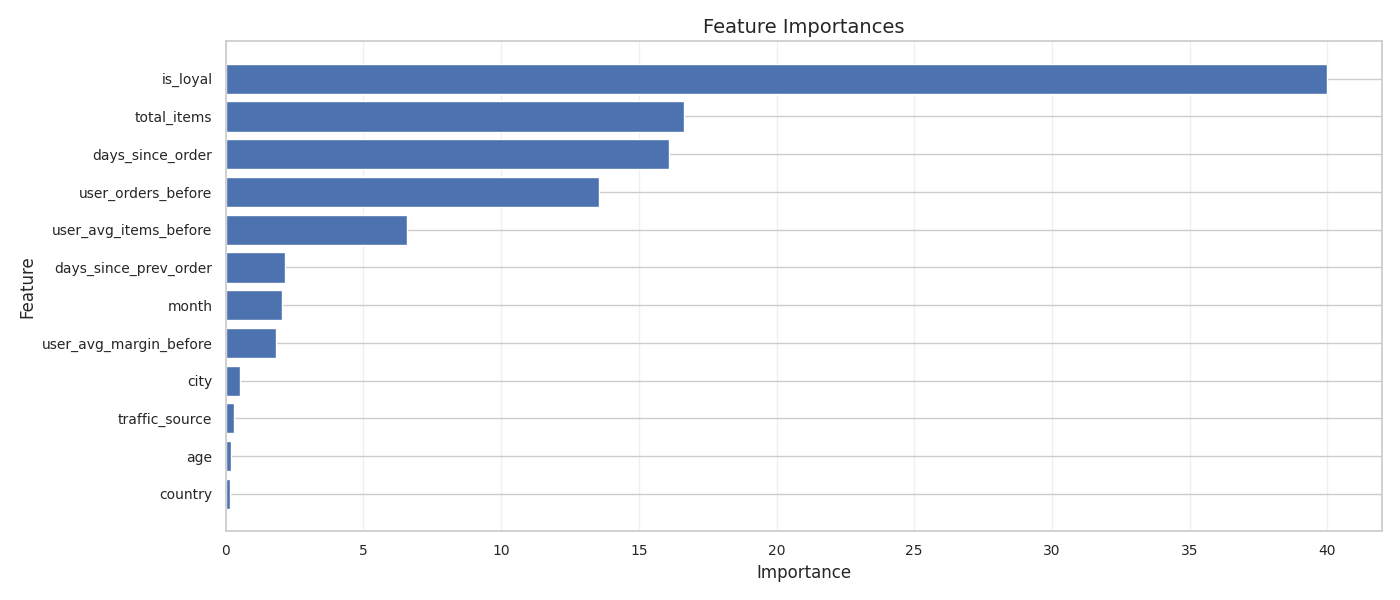

Users analyzed: 63660
Users needing intervention: 23810
Share needing intervention: 37.40%
Average churn probability: 0.5998
       user_id  order_id                created_at  will_return  prediction  \
40076    42650     53430 2023-01-25 02:16:16+00:00            1           1   
92942    99121    124042 2020-10-23 01:10:09+00:00            1           1   
26642    28493     35564 2025-09-17 13:29:53+00:00            1           1   
19726    21074     26319 2025-01-30 19:12:02+00:00            0           0   
73136    78122     97675 2025-07-22 02:46:24+00:00            1           0   

       probability_return  probability_churn  
40076            0.999324           0.000676  
92942            0.564491           0.435509  
26642            0.996307           0.003693  
19726            0.285300           0.714700  
73136            0.195361           0.804639  
       user_id  probability_return  probability_churn  need_intervention
64977    69273            0.001786           

In [97]:
model.print_metrics()
model.print_feature_importance()
model.plot_feature_importance()
model.print_business_statistics(orders)

predictions_table = model.get_predictions_table()
print(predictions_table.head())

risk_table = model.get_last_order_risk(orders=orders, churn_threshold=0.7)
print(
    risk_table[
        ["user_id", "probability_return", "probability_churn", "need_intervention"]
    ].head(20)
)

In [112]:
risk_table = model.get_last_order_risk(
    orders=orders,
    churn_threshold=0.7
)

result_table = risk_table[
    [
        "user_id",
        "order_id",
        "created_at",
        "is_loyal",
        "age",
        "country",
        "city",
        "traffic_source",
        "total_items",
        "user_orders_before",
        "user_avg_items_before",
        "user_avg_margin_before",
        "days_since_prev_order",
        "days_since_order",
        "probability_return",
        "probability_churn",
        "need_intervention"
    ]
].copy()

result_table = result_table.sort_values(
    "probability_churn",
    ascending=False
).reset_index(drop=True)

result_table.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print(result_table.head(20))
print(result_table.shape)
print("CSV сохранен: customer_churn_predictions.csv")

    user_id  order_id                created_at  is_loyal  age  \
0     69273     86743 2025-06-11 03:03:08+00:00      True   29   
1     31834     39788 2025-05-15 19:56:11+00:00      True   41   
2     32700     40880 2025-06-26 10:22:29+00:00     False   26   
3      4577      5679 2025-07-19 18:54:28+00:00      True   55   
4     64976     81364 2024-10-29 21:32:24+00:00     False   69   
5     74668     93358 2025-04-30 06:13:47+00:00      True   20   
6     88558    110645 2025-06-16 22:48:14+00:00     False   22   
7     97239    121683 2025-07-20 05:45:22+00:00     False   56   
8     45966     57583 2025-07-12 15:56:23+00:00     False   45   
9     35392     44272 2025-06-28 04:46:30+00:00     False   34   
10    19657     24544 2025-05-09 19:49:23+00:00      True   47   
11    34566     43245 2025-07-14 12:52:56+00:00      True   40   
12    89546    111858 2025-06-04 19:23:00+00:00      True   24   
13    34786     43540 2025-04-29 01:12:04+00:00      True   38   
14    3682

## Графики

THRESHOLDS ДЛЯ СОХРАНЕНИЯ ~30% КЛИЕНТОВ
Лояльные: threshold = 0.5352
Нелояльные: threshold = 0.7367
Лояльные клиенты с высоким риском: 30.00%
Нелояльные клиенты с высоким риском: 30.00%
Все клиенты с высоким риском: 30.00%


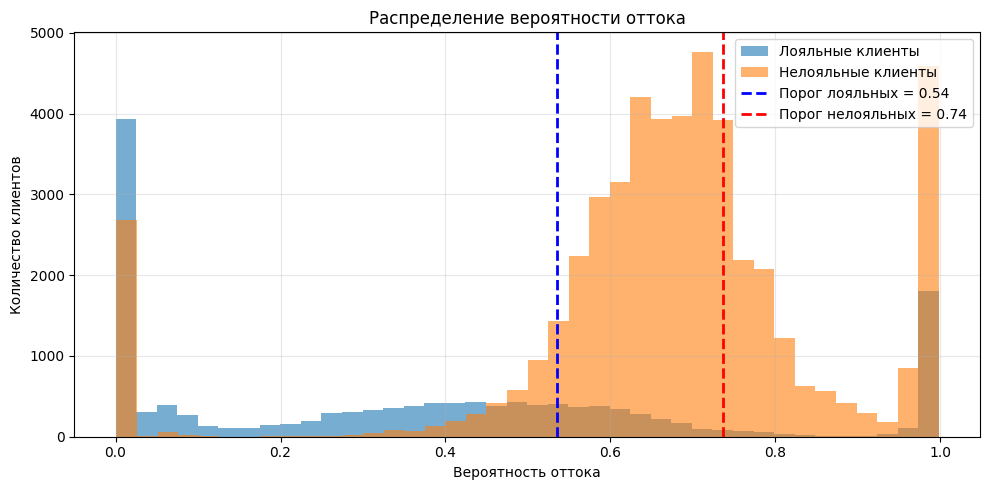

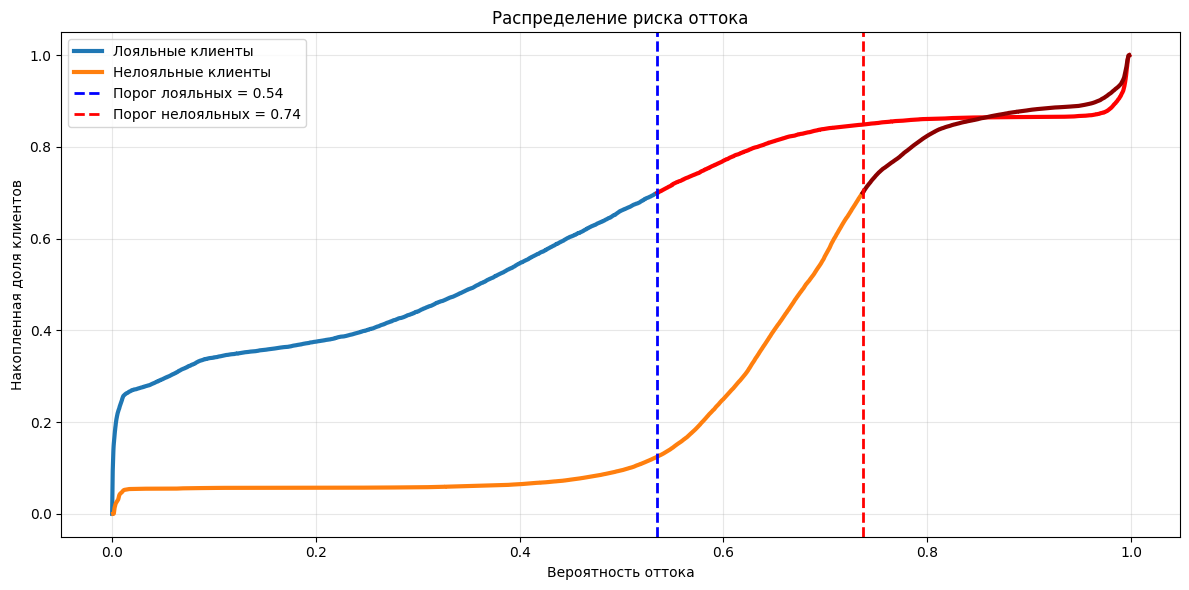

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ЗАГРУЗКА
# =========================
result_table = pd.read_csv(
    "customer_churn_predictions.csv",
    parse_dates=["created_at"]
)

# =========================
# РАЗДЕЛЕНИЕ НА ГРУППЫ
# =========================
loyal = result_table[result_table["is_loyal"] == 1].copy()
not_loyal = result_table[result_table["is_loyal"] == 0].copy()

# =========================
# ЦЕЛЕВАЯ ДОЛЯ КЛИЕНТОВ ДЛЯ ВМЕШАТЕЛЬСТВА
# =========================
target_share = 0.30

# индивидуальные thresholds для каждой группы
loyal_threshold = loyal["probability_churn"].quantile(1 - target_share)
not_loyal_threshold = not_loyal["probability_churn"].quantile(1 - target_share)

# =========================
# ПРОЦЕНТ КЛИЕНТОВ В ЗОНЕ РИСКА
# =========================
loyal_high_risk_share = (
    (loyal["probability_churn"] >= loyal_threshold).mean() * 100
)

not_loyal_high_risk_share = (
    (not_loyal["probability_churn"] >= not_loyal_threshold).mean() * 100
)

all_high_risk_share = (
    (
        (loyal["probability_churn"] >= loyal_threshold).sum() +
        (not_loyal["probability_churn"] >= not_loyal_threshold).sum()
    ) / len(result_table) * 100
)

print("=" * 60)
print("THRESHOLDS ДЛЯ СОХРАНЕНИЯ ~30% КЛИЕНТОВ")
print("=" * 60)
print(f"Лояльные: threshold = {loyal_threshold:.4f}")
print(f"Нелояльные: threshold = {not_loyal_threshold:.4f}")
print("=" * 60)
print(f"Лояльные клиенты с высоким риском: {loyal_high_risk_share:.2f}%")
print(f"Нелояльные клиенты с высоким риском: {not_loyal_high_risk_share:.2f}%")
print(f"Все клиенты с высоким риском: {all_high_risk_share:.2f}%")
print("=" * 60)

# =========================
# 1. ГИСТОГРАММА
# =========================
plt.figure(figsize=(10, 5))

plt.hist(
    loyal["probability_churn"],
    bins=40,
    alpha=0.6,
    label="Лояльные клиенты"
)

plt.hist(
    not_loyal["probability_churn"],
    bins=40,
    alpha=0.6,
    label="Нелояльные клиенты"
)

plt.axvline(
    loyal_threshold,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Порог лояльных = {loyal_threshold:.2f}"
)

plt.axvline(
    not_loyal_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Порог нелояльных = {not_loyal_threshold:.2f}"
)

plt.xlabel("Вероятность оттока")
plt.ylabel("Количество клиентов")
plt.title("Распределение вероятности оттока")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 2. КУМУЛЯТИВНОЕ РАСПРЕДЕЛЕНИЕ
# =========================
loyal_probs = np.sort(loyal["probability_churn"].values)
not_loyal_probs = np.sort(not_loyal["probability_churn"].values)

loyal_cum_share = np.arange(1, len(loyal_probs) + 1) / len(loyal_probs)
not_loyal_cum_share = np.arange(1, len(not_loyal_probs) + 1) / len(not_loyal_probs)

plt.figure(figsize=(12, 6))

# Лояльные
mask_loyal_left = loyal_probs < loyal_threshold
mask_loyal_right = loyal_probs >= loyal_threshold

plt.plot(
    loyal_probs[mask_loyal_left],
    loyal_cum_share[mask_loyal_left],
    linewidth=3,
    label="Лояльные клиенты"
)

plt.plot(
    loyal_probs[mask_loyal_right],
    loyal_cum_share[mask_loyal_right],
    linewidth=3,
    color="red"
)

# Нелояльные
mask_not_loyal_left = not_loyal_probs < not_loyal_threshold
mask_not_loyal_right = not_loyal_probs >= not_loyal_threshold

plt.plot(
    not_loyal_probs[mask_not_loyal_left],
    not_loyal_cum_share[mask_not_loyal_left],
    linewidth=3,
    label="Нелояльные клиенты"
)

plt.plot(
    not_loyal_probs[mask_not_loyal_right],
    not_loyal_cum_share[mask_not_loyal_right],
    linewidth=3,
    color="darkred"
)

plt.axvline(
    loyal_threshold,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Порог лояльных = {loyal_threshold:.2f}"
)

plt.axvline(
    not_loyal_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Порог нелояльных = {not_loyal_threshold:.2f}"
)

plt.xlabel("Вероятность оттока")
plt.ylabel("Накопленная доля клиентов")
plt.title("Распределение риска оттока")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Медианный интервал: 263.0 дней
Средний интервал: 391.8 дней
75-й перцентиль: 573.0 дней
90-й перцентиль: 957.0 дней


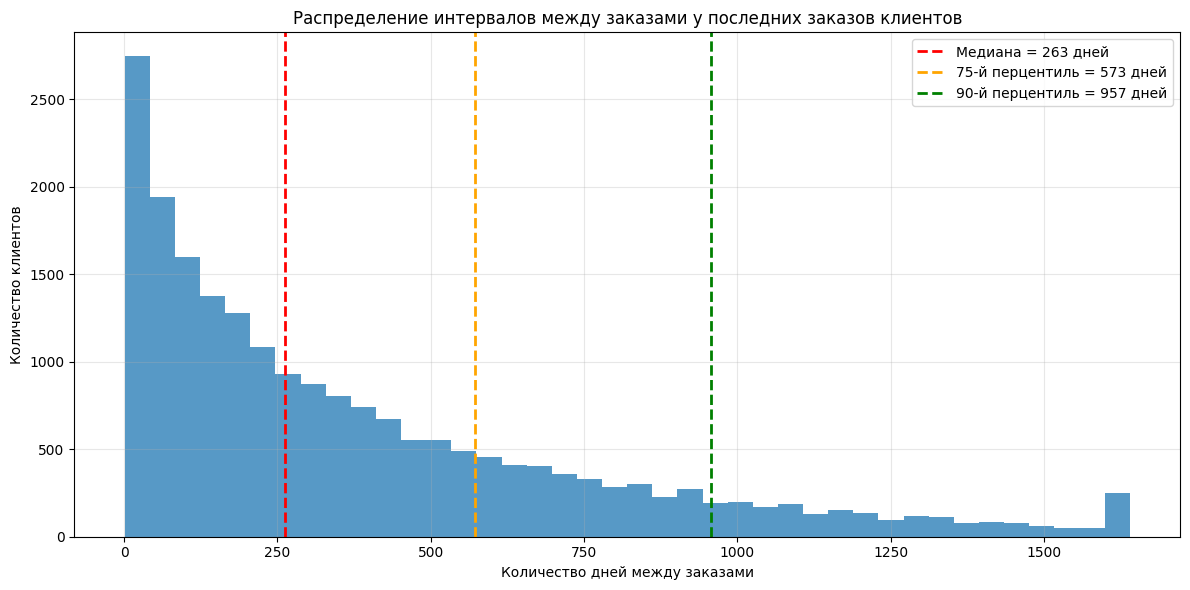

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# загружаем CSV
result_table = pd.read_csv(
    "customer_churn_predictions.csv",
    parse_dates=["created_at"]
)

# интервалы между заказами только для последних заказов пользователей
valid_intervals = result_table.loc[
    result_table["days_since_prev_order"].notna()
    & (result_table["days_since_prev_order"] > 0),
    "days_since_prev_order"
]

median_interval = valid_intervals.median()
mean_interval = valid_intervals.mean()
p75_interval = valid_intervals.quantile(0.75)
p90_interval = valid_intervals.quantile(0.90)

print(f"Медианный интервал: {median_interval:.1f} дней")
print(f"Средний интервал: {mean_interval:.1f} дней")
print(f"75-й перцентиль: {p75_interval:.1f} дней")
print(f"90-й перцентиль: {p90_interval:.1f} дней")

plt.figure(figsize=(12, 6))

plt.hist(
    valid_intervals.clip(upper=valid_intervals.quantile(0.99)),
    bins=40,
    alpha=0.75
)

plt.axvline(
    median_interval,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Медиана = {median_interval:.0f} дней"
)

plt.axvline(
    p75_interval,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"75-й перцентиль = {p75_interval:.0f} дней"
)

plt.axvline(
    p90_interval,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"90-й перцентиль = {p90_interval:.0f} дней"
)

plt.xlabel("Количество дней между заказами")
plt.ylabel("Количество клиентов")
plt.title("Распределение интервалов между заказами у последних заказов клиентов")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# загружаем CSV
result_table = pd.read_csv(
    "customer_churn_predictions.csv",
    parse_dates=["created_at"]
)

def show_customer_info(user_id, result_table):
    customer = result_table[result_table["user_id"] == user_id]

    if customer.empty:
        print(f"Пользователь {user_id} не найден")
        return

    customer = customer.iloc[0]

    print("=" * 60)
    print(f"Информация о пользователе {user_id}")
    print("=" * 60)

    print(f"order_id: {customer['order_id']}")
    print(f"Дата заказа: {customer['created_at']}")
    print(f"Лояльный клиент: {customer['is_loyal']}")
    print(f"Возраст: {customer['age']}")
    print(f"Страна: {customer['country']}")
    print(f"Город: {customer['city']}")
    print(f"Источник трафика: {customer['traffic_source']}")
    print(f"Количество товаров в заказе: {customer['total_items']}")
    print(f"Количество прошлых заказов: {customer['user_orders_before']}")
    print(f"Среднее число товаров в прошлых заказах: {customer['user_avg_items_before']:.2f}")
    print(f"Средняя маржа прошлых заказов: {customer['user_avg_margin_before']:.2f}")

    if pd.notna(customer["days_since_prev_order"]):
        print(f"Дней с прошлого заказа: {customer['days_since_prev_order']:.0f}")
    else:
        print("Дней с прошлого заказа: нет данных")

    print(f"Дней с текущего заказа: {customer['days_since_order']:.0f}")
    print(f"Вероятность возврата: {customer['probability_return']:.3f}")
    print(f"Вероятность оттока: {customer['probability_churn']:.3f}")
    print(f"Нужно вмешательство: {customer['need_intervention']}")
    print("=" * 60)

# пример
show_customer_info(user_id=12345, result_table=result_table)

Информация о пользователе 12345
order_id: 15502
Дата заказа: 2025-07-21 07:50:10+00:00
Лояльный клиент: False
Возраст: 24
Страна: Brasil
Город: Ceará-Mirim
Источник трафика: Search
Количество товаров в заказе: 3
Количество прошлых заказов: 0
Среднее число товаров в прошлых заказах: 0.00
Средняя маржа прошлых заказов: 0.00
Дней с прошлого заказа: 0
Дней с текущего заказа: 232
Вероятность возврата: 0.003
Вероятность оттока: 0.997
Нужно вмешательство: 1
